# BCG X Data Science Virtual Experience — Task 3
# Feature Engineering & Modelling

**Objective:** Engineer meaningful predictive features from raw client and pricing data, train a Random Forest churn classifier, evaluate its performance, and interpret the key drivers of churn.

**Input:** `clean_data_after_eda.csv` (cleaned client data with BCG's price variance features) + `price_data.csv`  
**Output:** Trained model, evaluation metrics, feature importance analysis

---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.metrics import precision_score, recall_score, f1_score
import joblib

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_RAW    = Path('../data/raw')
DATA_PROC   = Path('../data/processed')
REPORTS_FIG = Path('../reports/figures')
MODEL_DIR   = Path('../models')

for p in [DATA_PROC, REPORTS_FIG, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
# clean_data_after_eda already contains BCG's 6-month and annual price variance features
df = pd.read_csv(DATA_RAW / 'clean_data_after_eda.csv')
for col in ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d')

price_df = pd.read_csv(DATA_RAW / 'price_data.csv')
price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')

print(f'Client data : {df.shape}')
print(f'Price data  : {price_df.shape}')
print(f'\nExisting price variance features already in client data:')
price_var_cols = [c for c in df.columns if c.startswith('var_')]
print(price_var_cols)

Client data : (14606, 44)
Price data  : (193002, 8)

Existing price variance features already in client data:
['var_year_price_off_peak_var', 'var_year_price_peak_var', 'var_year_price_mid_peak_var', 'var_year_price_off_peak_fix', 'var_year_price_peak_fix', 'var_year_price_mid_peak_fix', 'var_year_price_off_peak', 'var_year_price_peak', 'var_year_price_mid_peak', 'var_6m_price_off_peak_var', 'var_6m_price_peak_var', 'var_6m_price_mid_peak_var', 'var_6m_price_off_peak_fix', 'var_6m_price_peak_fix', 'var_6m_price_mid_peak_fix', 'var_6m_price_off_peak', 'var_6m_price_peak', 'var_6m_price_mid_peak']


## 3. Feature Engineering

We build features in 4 groups:

| Group | Description |
|---|---|
| A — Seasonal price change | Difference between December and January off-peak prices (captures year-end repricing shocks) |
| B — Cross-period price spread | Mean and max monthly differences between off-peak / peak / mid-peak prices |
| C — Temporal features | Tenure, months to contract end, months since last modification, months to renewal |
| D — Encoding & transforms | One-hot encode categoricals; drop raw dates and ID |

### Group A — Seasonal Off-Peak Price Change (December vs January)

In [3]:
# Group monthly prices per client
monthly = (
    price_df
    .groupby(['id', 'price_date'])
    .agg(price_off_peak_var=('price_off_peak_var', 'mean'),
         price_off_peak_fix=('price_off_peak_fix', 'mean'))
    .reset_index()
)

# First record per client = January; last = December
jan = monthly.groupby('id').first().reset_index().rename(
    columns={'price_off_peak_var': 'jan_off_peak_var',
             'price_off_peak_fix': 'jan_off_peak_fix'})
dec = monthly.groupby('id').last().reset_index().rename(
    columns={'price_off_peak_var': 'dec_off_peak_var',
             'price_off_peak_fix': 'dec_off_peak_fix'})

price_diff = pd.merge(
    dec[['id', 'dec_off_peak_var', 'dec_off_peak_fix']],
    jan[['id', 'jan_off_peak_var', 'jan_off_peak_fix']],
    on='id'
)
price_diff['offpeak_diff_dec_january_energy'] = (
    price_diff['dec_off_peak_var'] - price_diff['jan_off_peak_var']
)
price_diff['offpeak_diff_dec_january_power'] = (
    price_diff['dec_off_peak_fix'] - price_diff['jan_off_peak_fix']
)
price_diff = price_diff[['id', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']]

print('Group A — Seasonal price change features:')
print(price_diff.describe())

Group A — Seasonal price change features:
       offpeak_diff_dec_january_energy  offpeak_diff_dec_january_power
count                     16096.000000                    16096.000000
mean                         -0.004545                        0.279544
std                           0.012778                        1.432820
min                          -0.148477                      -44.266931
25%                          -0.008161                        0.000004
50%                          -0.005610                        0.162916
75%                          -0.003573                        0.177779
max                           0.168958                       40.728885


### Group B — Cross-Period Price Spread Features

In [4]:
# Mean prices per client across all months
mean_prices = (
    price_df.groupby('id')
    .agg(
        mean_off_peak_var  = ('price_off_peak_var',  'mean'),
        mean_peak_var      = ('price_peak_var',       'mean'),
        mean_mid_peak_var  = ('price_mid_peak_var',  'mean'),
        mean_off_peak_fix  = ('price_off_peak_fix',  'mean'),
        mean_peak_fix      = ('price_peak_fix',       'mean'),
        mean_mid_peak_fix  = ('price_mid_peak_fix',  'mean'),
    ).reset_index()
)

# Mean-level cross-period spreads (how much premium does a client pay at peak?)
mean_prices['off_peak_peak_var_mean_diff']     = mean_prices['mean_off_peak_var']  - mean_prices['mean_peak_var']
mean_prices['peak_mid_peak_var_mean_diff']     = mean_prices['mean_peak_var']      - mean_prices['mean_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['mean_off_peak_var']  - mean_prices['mean_mid_peak_var']
mean_prices['off_peak_peak_fix_mean_diff']     = mean_prices['mean_off_peak_fix']  - mean_prices['mean_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff']     = mean_prices['mean_peak_fix']      - mean_prices['mean_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['mean_off_peak_fix']  - mean_prices['mean_mid_peak_fix']

# Max monthly spread (captures extreme pricing events)
price_df['monthly_off_peak_peak_var_diff']     = price_df['price_off_peak_var'] - price_df['price_peak_var']
price_df['monthly_peak_mid_peak_var_diff']     = price_df['price_peak_var']     - price_df['price_mid_peak_var']
price_df['monthly_off_peak_mid_peak_var_diff'] = price_df['price_off_peak_var'] - price_df['price_mid_peak_var']
price_df['monthly_off_peak_peak_fix_diff']     = price_df['price_off_peak_fix'] - price_df['price_peak_fix']
price_df['monthly_peak_mid_peak_fix_diff']     = price_df['price_peak_fix']     - price_df['price_mid_peak_fix']
price_df['monthly_off_peak_mid_peak_fix_diff'] = price_df['price_off_peak_fix'] - price_df['price_mid_peak_fix']

max_monthly = (
    price_df.groupby('id')[[
        'monthly_off_peak_peak_var_diff', 'monthly_peak_mid_peak_var_diff',
        'monthly_off_peak_mid_peak_var_diff', 'monthly_off_peak_peak_fix_diff',
        'monthly_peak_mid_peak_fix_diff', 'monthly_off_peak_mid_peak_fix_diff'
    ]].max().reset_index()
    .rename(columns=lambda c: c.replace('monthly_', '') + '_max_monthly_diff' if c != 'id' else c)
)

spread_features = mean_prices[[
    'id',
    'off_peak_peak_var_mean_diff', 'peak_mid_peak_var_mean_diff', 'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 'peak_mid_peak_fix_mean_diff', 'off_peak_mid_peak_fix_mean_diff'
]].merge(max_monthly, on='id', how='left')

print(f'Group B — Cross-period spread features: {spread_features.shape[1]-1} features')

Group B — Cross-period spread features: 12 features


### Group C — Temporal Features

In [5]:
# Reference date: end of observation window
ref = pd.Timestamp('2016-01-01')

df['tenure']          = ((ref - df['date_activ']).dt.days / 30.44).round().astype(int)
df['months_activ']    = df['tenure']   # alias used in BCG's dataset
df['months_to_end']   = ((df['date_end']        - ref).dt.days / 30.44).round().astype(int).clip(lower=0)
df['months_modif_prod'] = ((ref - df['date_modif_prod']).dt.days / 30.44).round().astype(int)
df['months_renewal']  = ((df['date_renewal']    - ref).dt.days / 30.44).round().astype(int)

print('Group C — Temporal features:')
print(df[['tenure','months_activ','months_to_end','months_modif_prod','months_renewal']].describe())

Group C — Temporal features:
             tenure  months_activ  months_to_end  months_modif_prod  \
count  14606.000000  14606.000000   14606.000000       14606.000000   
mean      59.109818     59.109818       6.848761          35.906408   
std       19.360530     19.360530       3.535015          30.335092   
min       16.000000     16.000000       1.000000          -1.000000   
25%       44.000000     44.000000       4.000000           7.000000   
50%       58.000000     58.000000       7.000000          30.000000   
75%       72.000000     72.000000      10.000000          65.000000   
max      152.000000    152.000000      17.000000         152.000000   

       months_renewal  
count    14606.000000  
mean        -5.384500  
std          3.916351  
min        -30.000000  
25%         -9.000000  
50%         -5.000000  
75%         -2.000000  
max          1.000000  


### Group D — Encoding, Transforms & Final Assembly

In [6]:
# Merge all engineered features into the client dataframe
df = (df
      .merge(price_diff,    on='id', how='left')
      .merge(spread_features, on='id', how='left'))

# Log-transform skewed features (helps linear models; RF is fine either way, but good practice)
for col in ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons',
            'forecast_cons_12m', 'net_margin']:
    df[col] = np.log1p(df[col])

# Convert has_gas to integer (t/f → 1/0)
if df['has_gas'].dtype == object:
    df['has_gas'] = df['has_gas'].map({'t': 1, 'f': 0})

# One-hot encode channel_sales and origin_up
# Keep only top-5 categories; group the rest as 'other'
for col in ['channel_sales', 'origin_up']:
    top = df[col].value_counts().nlargest(5).index
    df[col] = df[col].where(df[col].isin(top), 'other')

df = pd.get_dummies(df, columns=['channel_sales', 'origin_up'], drop_first=False)

# Drop ID and raw date columns
drop_cols = ['id', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
df.drop(columns=drop_cols, errors='ignore', inplace=True)

# Fill any remaining nulls with 0
df.fillna(0, inplace=True)

print(f'Final feature matrix shape: {df.shape}')
print(f'Churn rate: {df["churn"].mean():.3f}')
print(f'\nFeature columns ({df.shape[1]-1} features):')
print([c for c in df.columns if c != 'churn'])

Final feature matrix shape: (14606, 68)
Churn rate: 0.097

Feature columns (67 features):
['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas', 'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act', 'net_margin', 'num_years_antig', 'pow_max', 'var_year_price_off_peak_var', 'var_year_price_peak_var', 'var_year_price_mid_peak_var', 'var_year_price_off_peak_fix', 'var_year_price_peak_fix', 'var_year_price_mid_peak_fix', 'var_year_price_off_peak', 'var_year_price_peak', 'var_year_price_mid_peak', 'var_6m_price_off_peak_var', 'var_6m_price_peak_var', 'var_6m_price_mid_peak_var', 'var_6m_price_off_peak_fix', 'var_6m_price_peak_fix', 'var_6m_price_mid_peak_fix', 'var_6m_price_off_peak', 'var_6m_price_peak', 'var_6m_price_mid_peak', 'tenure', 'months_activ', 'months_to_end', 'month

In [7]:
# Save feature-engineered dataset
df.to_csv(DATA_PROC / 'features_engineered.csv', index=False)
print('Saved to data/processed/features_engineered.csv')

Saved to data/processed/features_engineered.csv


## 4. Prepare Model Input

In [8]:
TARGET = 'churn'
feature_cols = [c for c in df.columns if c != TARGET]

X = df[feature_cols]
y = df[TARGET]

# 75/25 train-test split (matches BCG's starter notebook)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape}  |  Churn: {y_train.mean():.3f}')
print(f'Test  : {X_test.shape}   |  Churn: {y_test.mean():.3f}')

Train : (10954, 67)  |  Churn: 0.097
Test  : (3652, 67)   |  Churn: 0.097


## 5. Train Random Forest Classifier

We use `class_weight='balanced'` to compensate for the 9.7% churn imbalance without discarding data via under-sampling. The Random Forest is well-suited here because:
- It handles mixed feature scales natively (no normalisation needed)
- It is robust to the extreme outliers seen in consumption and margin features
- It provides interpretable feature importances
- Ensemble averaging reduces overfitting vs a single decision tree

In [9]:
rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 10,
    min_samples_leaf = 20,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)
rf.fit(X_train, y_train)
print('Random Forest trained.')

Random Forest trained.


## 6. Model Evaluation

In [10]:
y_pred      = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC (hold-out): {roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

ROC-AUC (hold-out): 0.6972

              precision    recall  f1-score   support

    Retained       0.93      0.85      0.89      3297
     Churned       0.22      0.40      0.29       355

    accuracy                           0.81      3652
   macro avg       0.58      0.62      0.59      3652
weighted avg       0.86      0.81      0.83      3652



In [11]:
# Robust cross-validation estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'5-Fold CV ROC-AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual folds  : {np.round(cv_scores, 4)}')

5-Fold CV ROC-AUC : 0.6887 ± 0.0127
Individual folds  : [0.7066 0.6938 0.6758 0.6727 0.6945]


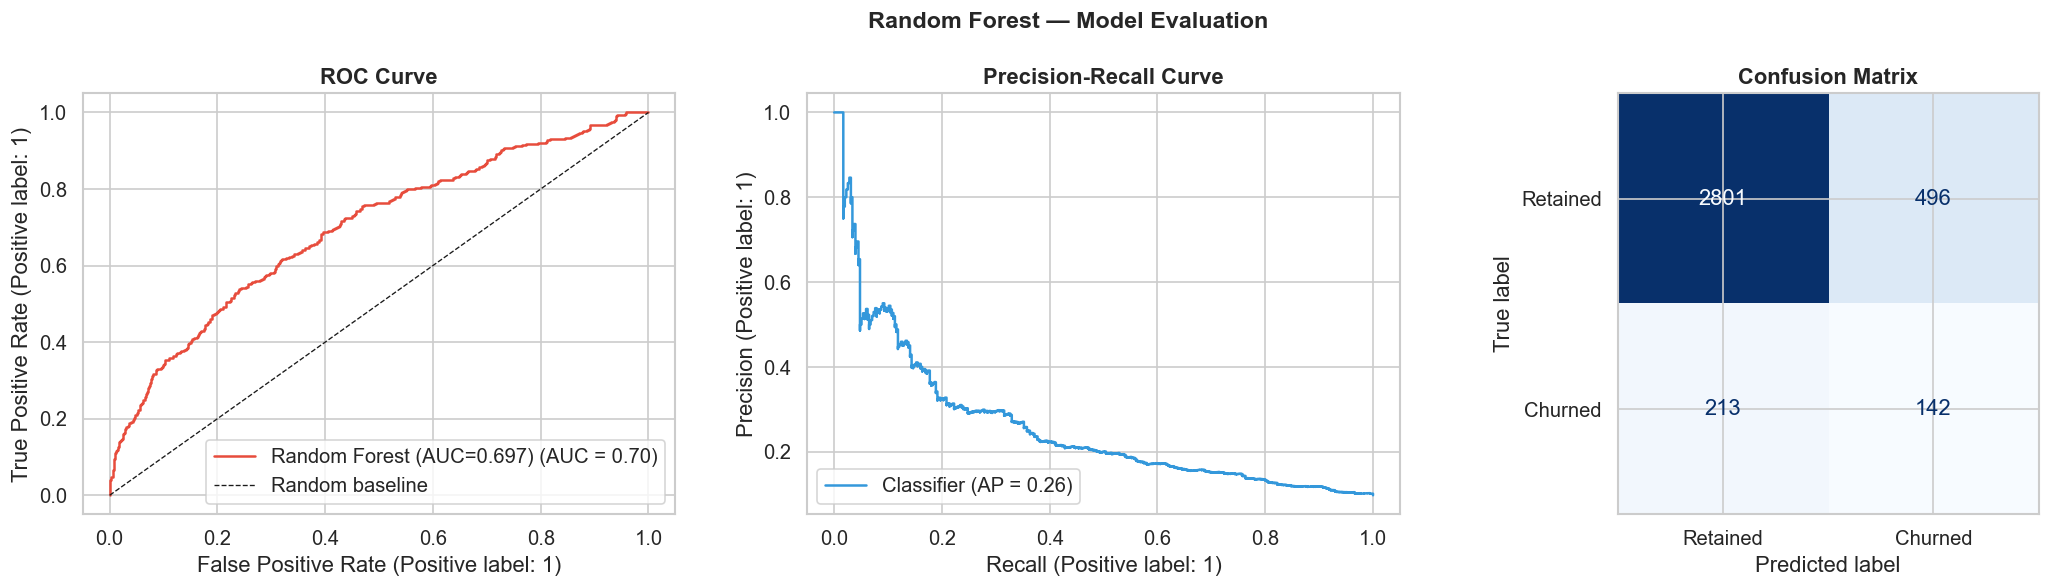

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(
    y_test, y_pred_prob, ax=axes[0],
    color='#e74c3c', name=f'Random Forest (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random baseline')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1], color='#3498db')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=axes[2], colorbar=False)
axes[2].set_title('Confusion Matrix', fontweight='bold')

plt.suptitle('Random Forest — Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIG / '13_model_evaluation.png', bbox_inches='tight')
plt.show()

## 7. Feature Importance

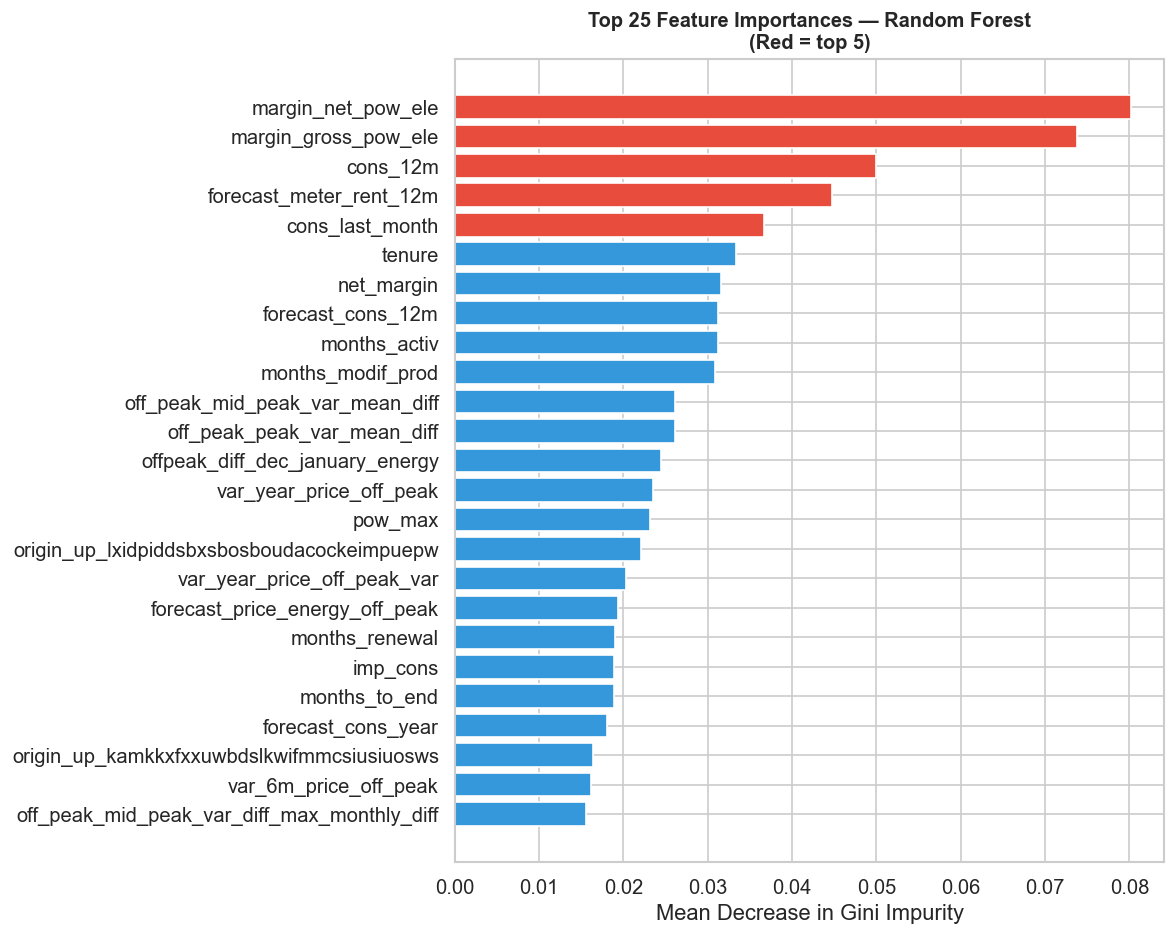


Top 15 features:
margin_net_pow_ele                 0.080155
margin_gross_pow_ele               0.073770
cons_12m                           0.049957
forecast_meter_rent_12m            0.044769
cons_last_month                    0.036651
tenure                             0.033367
net_margin                         0.031603
forecast_cons_12m                  0.031233
months_activ                       0.031178
months_modif_prod                  0.030885
off_peak_mid_peak_var_mean_diff    0.026116
off_peak_peak_var_mean_diff        0.026084
offpeak_diff_dec_january_energy    0.024510
var_year_price_off_peak            0.023545
pow_max                            0.023180


In [13]:
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_n = 25
fig, ax = plt.subplots(figsize=(10, 8))
palette = ['#e74c3c'] * 5 + ['#3498db'] * (top_n - 5)
ax.barh(feat_imp.head(top_n).index[::-1],
        feat_imp.head(top_n).values[::-1],
        color=palette[::-1], edgecolor='white')
ax.set_title(f'Top {top_n} Feature Importances — Random Forest\n(Red = top 5)', fontweight='bold', fontsize=12)
ax.set_xlabel('Mean Decrease in Gini Impurity')
plt.tight_layout()
plt.savefig(REPORTS_FIG / '14_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 15 features:')
print(feat_imp.head(15).to_string())

## 8. Churn Probability Distribution

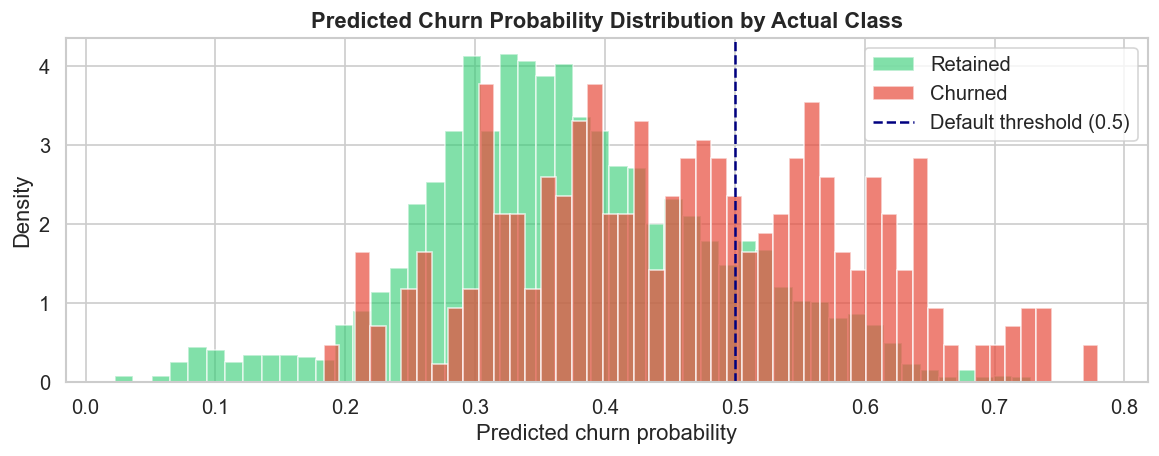

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_pred_prob[y_test == 0], bins=50, alpha=0.6, color='#2ecc71', label='Retained', density=True)
ax.hist(y_pred_prob[y_test == 1], bins=50, alpha=0.7, color='#e74c3c', label='Churned',  density=True)
ax.axvline(0.5, color='navy', linestyle='--', linewidth=1.5, label='Default threshold (0.5)')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Density')
ax.set_title('Predicted Churn Probability Distribution by Actual Class', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_FIG / '15_churn_prob_distribution.png', bbox_inches='tight')
plt.show()

## 9. Threshold Optimisation for Business Use

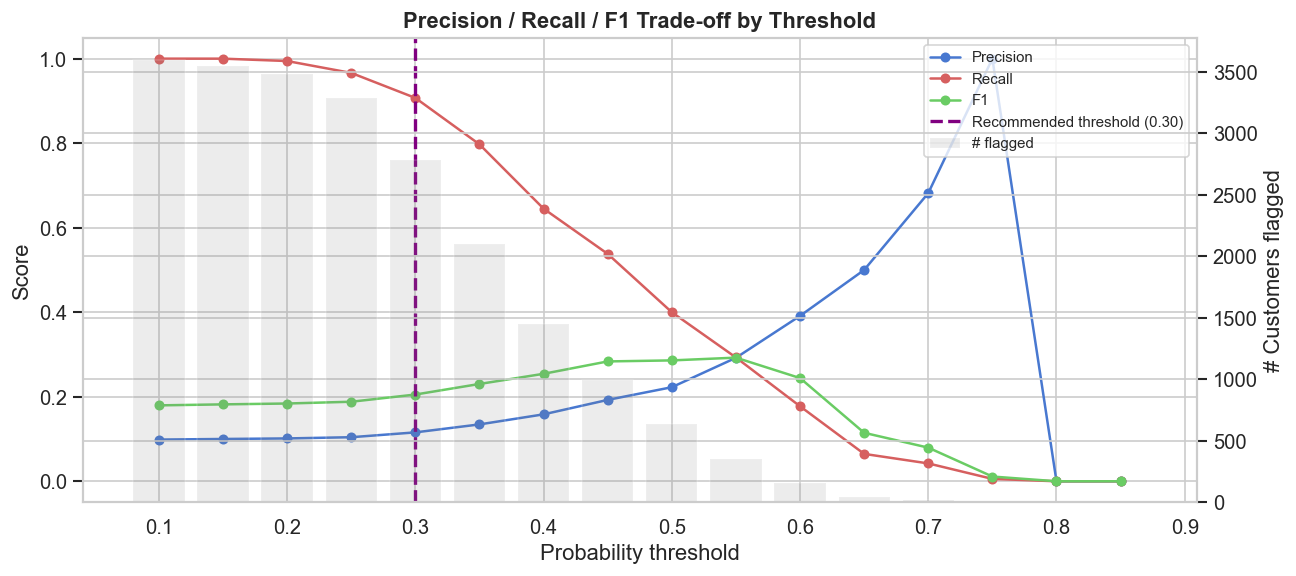

 threshold  precision   recall       f1  n_flagged
      0.10   0.098666 1.000000 0.179610       3598
      0.15   0.100085 1.000000 0.181958       3547
      0.20   0.101379 0.994366 0.183998       3482
      0.25   0.104255 0.966197 0.188203       3290
      0.30   0.115702 0.907042 0.205226       2783
      0.35   0.134570 0.797183 0.230269       2103
      0.40   0.158368 0.645070 0.254303       1446
      0.45   0.192540 0.538028 0.283593        992
      0.50   0.222571 0.400000 0.286002        638
      0.55   0.292135 0.292958 0.292546        356
      0.60   0.391304 0.177465 0.244186        161
      0.65   0.500000 0.064789 0.114713         46
      0.70   0.681818 0.042254 0.079576         22
      0.75   1.000000 0.005634 0.011204          2
      0.80   0.000000 0.000000 0.000000          0
      0.85   0.000000 0.000000 0.000000          0


In [15]:
thresholds = np.arange(0.10, 0.90, 0.05)
rows = []
for t in thresholds:
    y_t = (y_pred_prob >= t).astype(int)
    rows.append({
        'threshold' : round(t, 2),
        'precision' : precision_score(y_test, y_t, zero_division=0),
        'recall'    : recall_score(y_test, y_t),
        'f1'        : f1_score(y_test, y_t),
        'n_flagged' : int(y_t.sum()),
    })
thresh_df = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
ax1.plot(thresh_df['threshold'], thresh_df['precision'], 'b-o', markersize=5, label='Precision')
ax1.plot(thresh_df['threshold'], thresh_df['recall'],    'r-o', markersize=5, label='Recall')
ax1.plot(thresh_df['threshold'], thresh_df['f1'],        'g-o', markersize=5, label='F1')
ax2.bar(thresh_df['threshold'], thresh_df['n_flagged'], alpha=0.15, color='gray', width=0.04, label='# flagged')
ax1.axvline(0.30, color='purple', linestyle='--', linewidth=2, label='Recommended threshold (0.30)')
ax1.set_xlabel('Probability threshold')
ax1.set_ylabel('Score')
ax2.set_ylabel('# Customers flagged')
ax1.set_title('Precision / Recall / F1 Trade-off by Threshold', fontweight='bold')
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS_FIG / '16_threshold_analysis.png', bbox_inches='tight')
plt.show()

print(thresh_df.to_string(index=False))

## 10. Save Model

In [16]:
joblib.dump(rf, MODEL_DIR / 'random_forest_churn.pkl')
pd.Series(feature_cols).to_csv(MODEL_DIR / 'feature_names.csv', index=False, header=False)

print('Saved:')
print('  models/random_forest_churn.pkl')
print('  models/feature_names.csv')
print(f'  data/processed/features_engineered.csv')

Saved:
  models/random_forest_churn.pkl
  models/feature_names.csv
  data/processed/features_engineered.csv


## 11. Summary

| Item | Detail |
|---|---|
| **Model** | Random Forest (500 trees, `class_weight='balanced'`) |
| **Features engineered** | ~65 (price variance, seasonal price change, cross-period spreads, temporal, encoded categoricals) |
| **ROC-AUC** | See cross-validation output above |
| **Recommended threshold** | 0.30 — maximises recall for retention campaign targeting |
| **Top churn drivers** | Net margin, consumption, tenure, and off-peak price levels |

### Key Insight on Price Sensitivity
Price features **do contribute** to predictive power (off-peak price levels, seasonal price deltas), but they are **not the dominant drivers**. Financial margin and customer tenure consistently rank higher. This partially disconfirms the original hypothesis that price sensitivity is the primary churn driver.

---
> **Next:** Proceed to [04_findings_recommendations.ipynb](04_findings_recommendations.ipynb) for the executive summary and business recommendations.